# AG-HYPOPT · Trial 05

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Four trials are recorded. Best is trial_03 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215) at objective 0.1040 (0 diverged, gamma finite; mu rel-RMSE 45.8%, gamma rel-RMSE 23.3%) - below the experiment_5 honest level (~0.108-0.113) and the 0.1074 headline. The rest: trial_04 (sw 0.959, h_f 2.101, h_s 2.126, cap 0.249) 0.1177; trial_01 (sw 0.409, h_s 3.354, h_f 1.837, cap 0.156) 0.1243; trial_02 (sw 0.884, h_f 0.642, h_s 1.007, cap 0.054) 0.1287. All have 0 diverged cells and finite gamma. The productive region is flat kernels (h_f ~2.4, h_s ~3.0) with a strong sigma link (sw ~0.96); sharpening either kernel hurt. 4/5 uniform-phase trials completed, so this batch is the last set of independent random draws before proposals become trials-informed.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_05'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (4/5 trials)
ID |     ei | params
 1 |      - | {"gamma_rel_cap": 0.4025014618726901, "h_f_scale": 3.2797779615118516, "h_s_scale": 2.1824708539080326, "sigma_weight": 0.2858013800881416}
 2 |      - | {"gamma_rel_cap": 0.026965351190828213, "h_f_scale": 1.6876333029456934, "h_s_scale": 1.781774520324995, "sigma_weight": 0.045275193902445166}
 3 |      - | {"gamma_rel_cap": 0.02437885536358403, "h_f_scale": 3.996910431494018, "h_s_scale": 2.696384168454954, "sigma_weight": 0.23451020166982395}
 4 |      - | {"gamma_rel_cap": 0.21747377611257102, "h_f_scale": 3.9031982247222077, "h_s_scale": 3.616291030407058, "sigma_weight": 0.844231037608741}
 5 |      - | {"gamma_rel_cap": 0.19620233216738908, "h_f_scale": 2.0988363202440348, "h_s_scale": 2.787585069366498, "sigma_weight": 0.06080271295805606}
 6 |      - | {"gamma_rel_cap": 0.2777980584603617, "h_f_scale": 1.2679435169878808, "h_s_scale": 3.548691900005958, "sigma_weight": 0.06421443731219101}
 7 |      - | {"gamma_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Registry: best is trial_03 (sw 0.956, h_f 2.450, h_s 3.017, cap 0.215) at 0.1040, in a region of flat kernels with a strong sigma link. trial_04 (0.1177) sharpened both kernels (h_f 2.10, h_s 2.13) from there and got worse, so the sharp side of the kernel-flatness axis is inferior; the flat side is not yet bracketed. Uniform phase (4/5) - the last fully-random batch.

The most informative draw probes the flat side of that axis: candidate 4 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) keeps a strong sigma link and a modest gamma cap like the best point but makes both kernels flatter (h_f 2.45 -> 3.90, h_s 3.02 -> 3.62). It brackets the kernel-flatness optimum from the opposite side to trial_04 and lies closest to the best region among the candidates.

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # candidate 4: sigma_weight 0.844, h_f_scale 3.903, h_s_scale 3.616, gamma_rel_cap 0.217 (flat kernels, strong sw)


chosen: {'gamma_rel_cap': 0.21747377611257102, 'h_f_scale': 3.9031982247222077, 'h_s_scale': 3.616291030407058, 'sigma_weight': 0.844231037608741}
Running  1nW Trans05 ... 

μ 9.39 -> 6.11 | γ 8.5 -> 7.67 | NLL 0.26


Running  1nW Trans20 ... 

μ 17.32 -> 27.69 | γ 8.5 -> 5.45 | NLL 0.66


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.69 | γ 14.1 -> 13.92 | NLL 0.73


Running 3nW Trans100 ... 

μ 175.71 -> 98.15 | γ 14.1 -> 13.79 | NLL 0.69



Total: 7.5 min


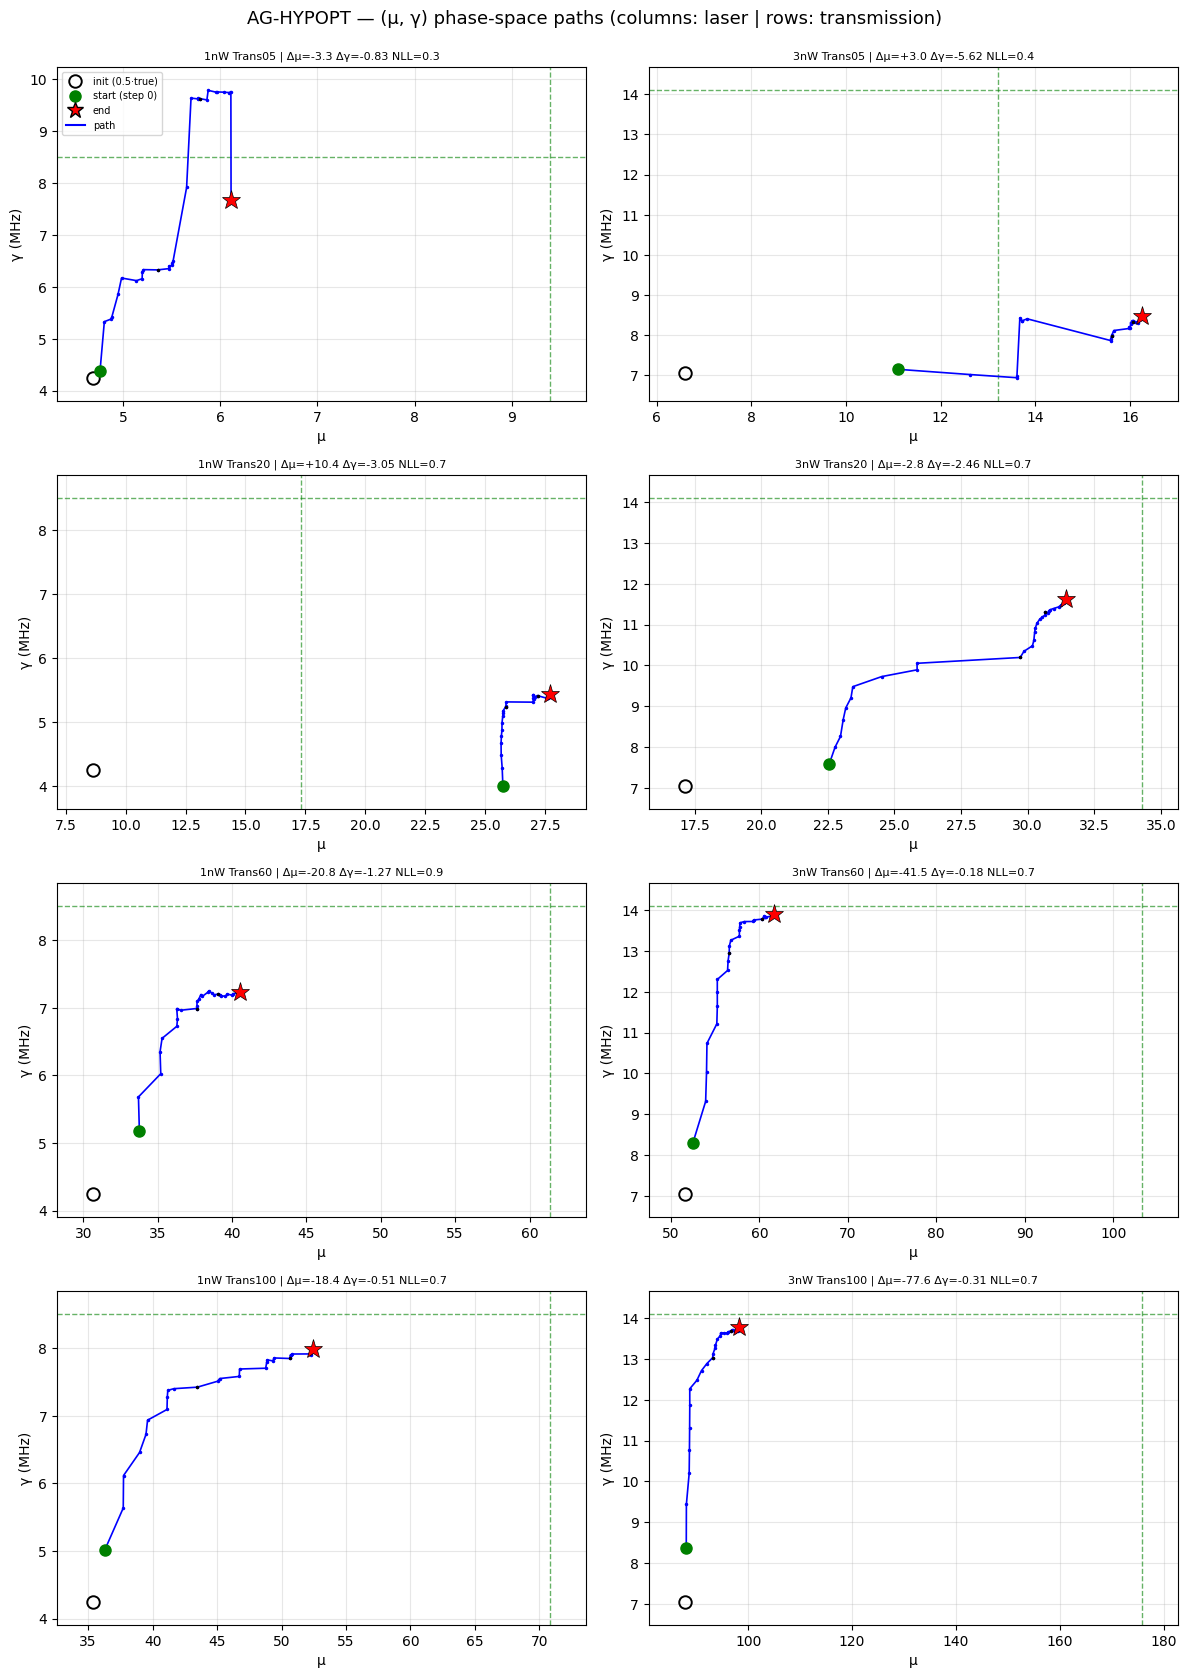

trial finished in 7.5 min
objective = 0.0822 ± 0.0244
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.11   -34.9 |     8.50    7.67    -9.7
1nW Trans20       17.32   27.69   +59.9 |     8.50    5.45   -35.9
1nW Trans60       61.37   40.54   -33.9 |     8.50    7.23   -15.0
1nW Trans100       70.82   52.47   -25.9 |     8.50    7.99    -6.0
3nW Trans05       13.20   16.24   +23.0 |    14.10    8.48   -39.8
3nW Trans20       34.28   31.44    -8.3 |    14.10   11.64   -17.5
3nW Trans60      103.20   61.69   -40.2 |    14.10   13.92    -1.3
3nW Trans100      175.71   98.15   -44.1 |    14.10   13.79    -2.2

weighted objective (T-graded, cap=1.0) = 0.0822 | diverged cells: 0
μ: RMSE 32.873 (rel 36.7%, bias -18.869) | γ: RMSE 2.490 (rel 21.0%, bias -1.779)


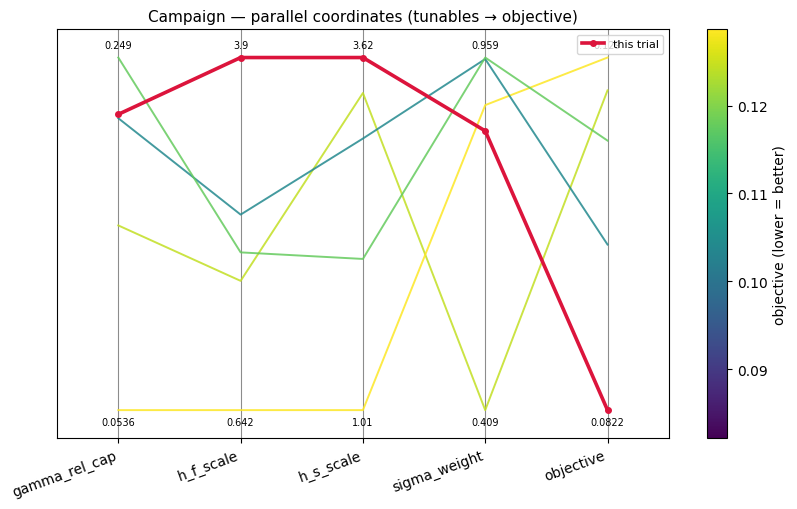

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 05 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) ran to completion in 7.5 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0822 +/- 0.0244 - a new best by a wide margin, well below the experiment_5 honest level (~0.108-0.113) and the 0.1074 headline, and also the smallest sampling SE so far.

mu rel-RMSE 36.7% (best so far; trial_03 45.8%, trial_04 50.4%, trial_01 58.1%): the pattern persists - undershoot at high T (3nW Trans100 -44.1%, 3nW Trans60 -40.2%, 1nW Trans60 -33.9%, 1nW Trans100 -25.9%) and overshoot at low T (1nW Trans20 +59.9%, 3nW Trans05 +23.0%) - but the magnitudes are the smallest yet; bias -18.87.

gamma rel-RMSE 21.0% (best so far; trial_03 23.3%): low-T cells still low (3nW Trans05 -39.8%, 1nW Trans20 -35.9%, 1nW Trans60 -15.0%) while high T is near the truth (3nW Trans60 -1.3%, 3nW Trans100 -2.2%, 1nW Trans100 -6.0%).

This candidate kept the strong-sigma + modest-cap design (sw 0.844, cap 0.217) and pushed both kernels flatter than the previous best (h_f 2.45 -> 3.90, h_s 3.02 -> 3.62), improving the objective 0.1040 -> 0.0822. Together with trial_04 (sharpening hurt), the evidence now says the objective falls monotonically with kernel flatness across the sampled range, with both kernels headed toward their upper bounds.

**Summary:** Trial 05 (sw=0.844, h_f=3.903, h_s=3.616, cap=0.217) finished in 7.5 min with 0 diverged cells and gamma finite, objective 0.0822 +/- 0.0244 - new best by a wide margin, well below the exp5 level and the 0.1074 headline (mu rel-RMSE 36.7%, gamma rel-RMSE 21.0%).
**Key insight:** Pushing both KDE kernels toward their upper bounds (h_f 3.90, h_s 3.62) with a strong sigma link gave the best result yet (0.0822), confirming kernel flatness as the dominant lever over the sigma weight.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 05 (sw=0.844, h_f=3.903, h_s=3.616, cap=0.217): objective 0.0822 +/- 0.0244 - new best by a wide margin, well below the exp5 level and the 0.1074 headline; 0 diverged cells, gamma finite (mu rel-RMSE 36.7%, gamma rel-RMSE 21.0%).'
KEY_INSIGHT = 'Pushing both KDE kernels toward their upper bounds (h_f 3.90, h_s 3.62) with a strong sigma link gave the best result yet (0.0822), confirming kernel flatness as the dominant lever over the sigma weight.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_05 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_06.ipynb. Open it and follow its cells from the top.
